инфо из гпт: https://www.perplexity.ai/search/1-fixed-acidity-2-volatile-aci-3ft6h_eJTP.aUf0Zk_s1iQ?preview=1#0

# 1. Импорт библиотек


In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 2. Загрузка и первый взгляд на данные

In [15]:
df = pd.read_csv('advertising.csv')
display(df.head())
print(df.info())
print(df.describe())

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


# 3. Подготовка данных

In [16]:
features = ['TV', 'Radio', 'Newspaper']
X = df[features]
y = df['Sales']

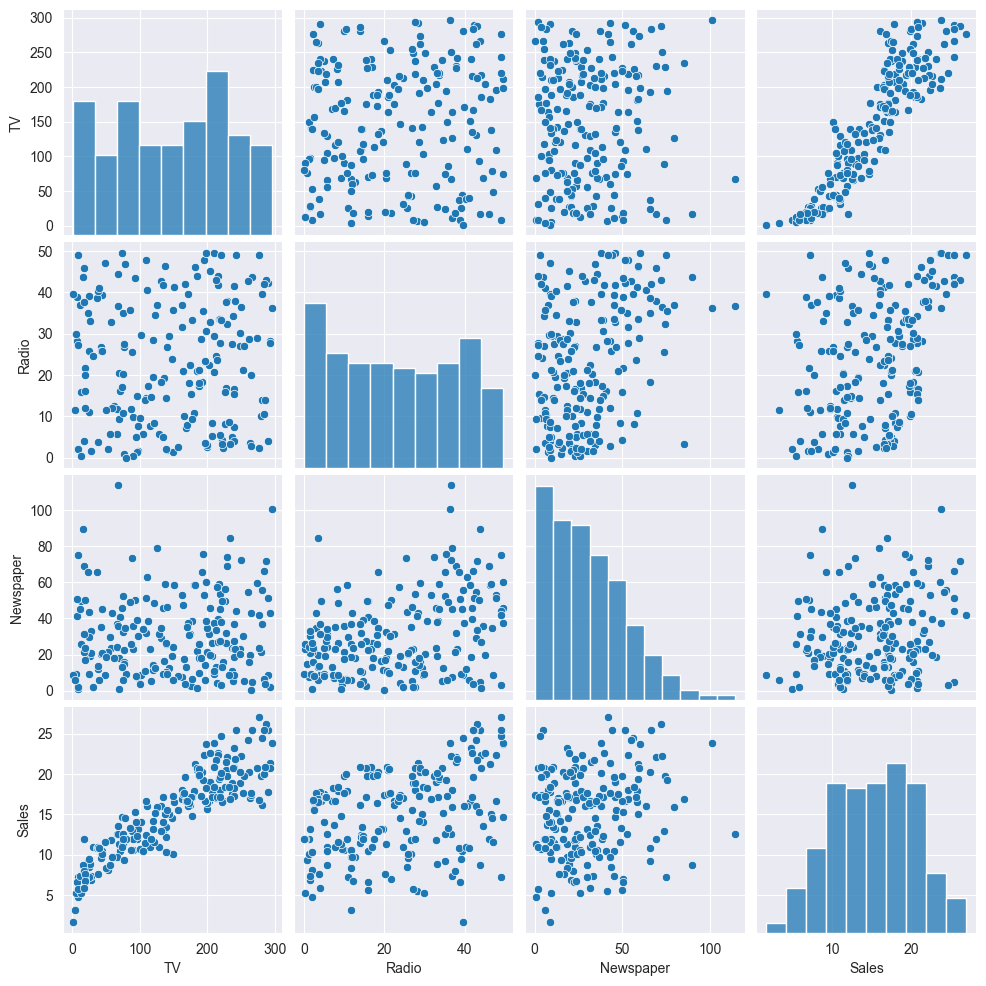

In [17]:
g=sns.pairplot(df[['TV', 'Radio', 'Newspaper', 'Sales']],)

1
2
3


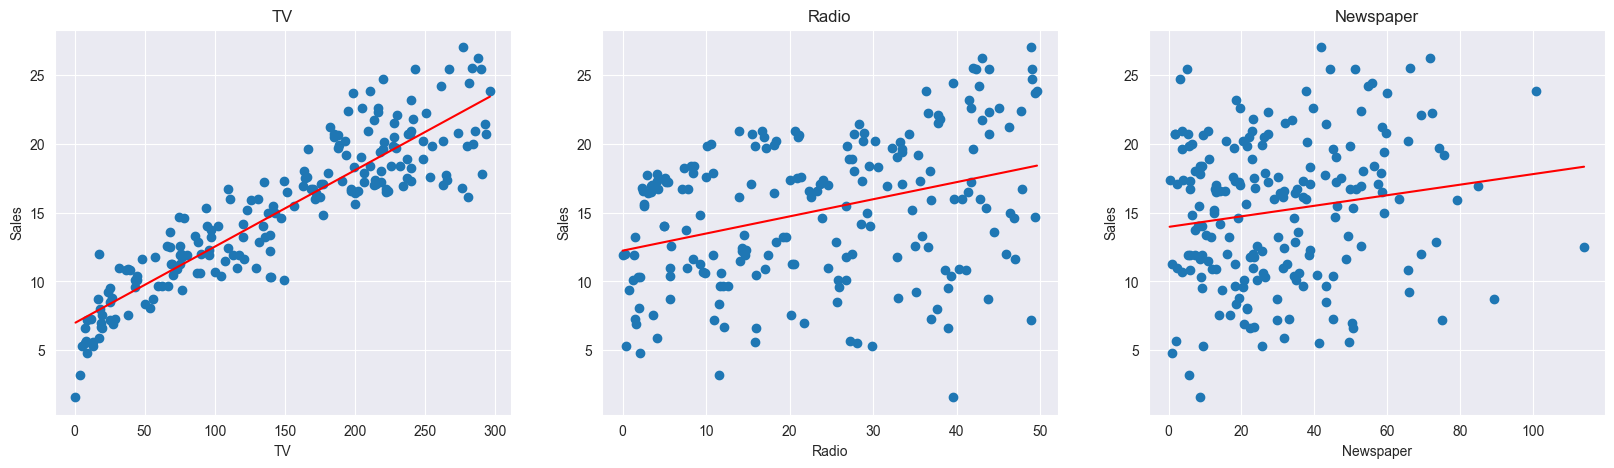

In [18]:
plt.figure(figsize=(20,5))
for i, col in enumerate(features):
    print(i+1)
    plt.subplot(1,3,i+1)
    x=df[col]
    y=df.Sales
    plt.plot(x,y,'o')
    plt.plot(np.unique(x), np.poly1d(np.polyfit(x,y,1))(np.unique(x)),color='r')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Sales')

# 4. Разделение на обучающую и тестовую выборки

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

# 5. Стандартизация признаков

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Обучение простой модели регрессии

In [26]:
regr = SGDRegressor(random_state=42)
regr.fit(X_train_scaled, y_train)
y_pred = regr.predict(X_test_scaled)
y_pred

array([10.66733565,  8.64919614,  9.58439492, 25.05763805, 14.74946916,
        8.37193244, 10.79009071, 18.34471736, 10.03468511, 17.85839944,
       23.59031057, 10.69878069, 13.33690575, 17.06959414, 11.75747366,
       13.28054722, 21.09029435,  9.06932887, 14.27583982, 18.84693946,
       25.10310092, 12.38650313, 16.62884871, 13.85510437,  7.78399427,
       15.10339156, 14.67757804, 20.69526768, 16.96341018,  8.97333552,
       12.75257652, 21.00270947, 21.36826002, 21.89294658,  7.27170952,
        7.04306885,  9.30584232, 15.74237545, 13.35438246,  7.28407654,
       11.12538179,  9.03424446, 15.57972376, 18.18972597, 19.01755403,
       13.43738349,  5.30363749, 10.71003014, 15.75955912, 10.989939  ,
       12.21267096, 20.80492591, 20.71692495, 16.95164983,  9.94834356,
        9.42038121, 23.64518876, 15.99797706, 18.07873746,  8.27607623,
       19.33898412, 15.62950611, 17.04696147, 15.24246343, 18.3570046 ,
       20.24477579])

# 7. Оценка качества модели

In [27]:
mae = metrics.mean_absolute_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)
print(f'MAE: {mae:.3f}  R^2: {r2:.3f}')

MAE: 1.348  R^2: 0.867


# 8. Визуализация — сравнение предсказаний и настоящих значений

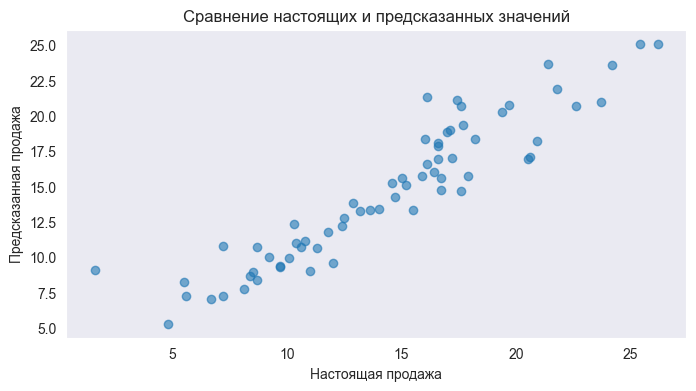

In [23]:
plt.figure(figsize=(8, 4))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel('Настоящая продажа')
plt.ylabel('Предсказанная продажа')
plt.title('Сравнение настоящих и предсказанных значений')
plt.grid()
plt.show()

# 9. Дополнительный анализ: гистограмма ошибок

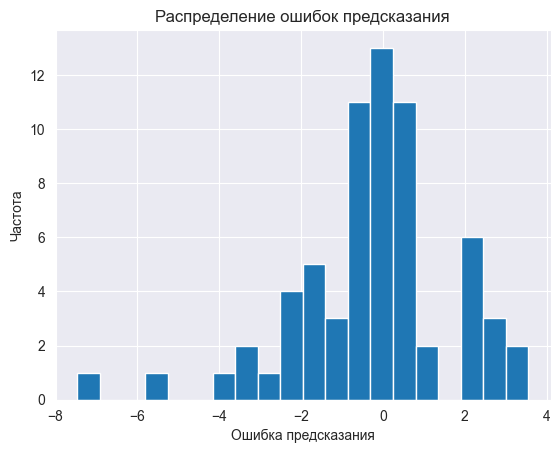

In [24]:
errors = y_test - y_pred
plt.hist(errors, bins=20)
plt.xlabel('Ошибка предсказания')
plt.ylabel('Частота')
plt.title('Распределение ошибок предсказания')
plt.show()

# 10. Корреляция признаков и продажи

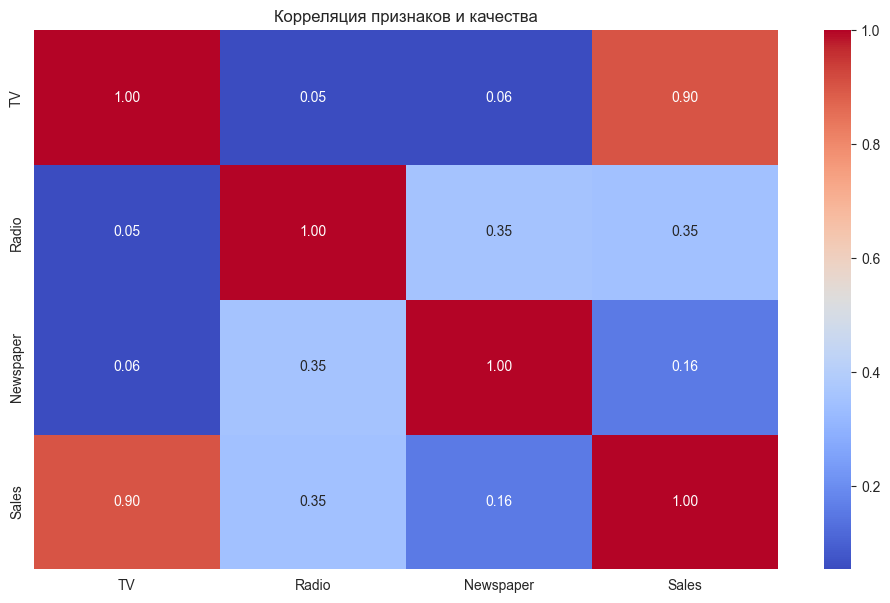

In [25]:
corr = df[features+['Sales']].corr()
plt.figure(figsize=(12,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title(' 10. Корреляция признаков и продажи')
plt.show()